# Chapter 3: Fitting the Curve
### *Loss Distributions and Heavy Tails*

Two years in, 800 policies, and a claims database that is telling you something uncomfortable.

The Chapter 1 model assumed every ransomware incident costs exactly 250K. The actual claims range from $18K (a small containment) to 4.2M (a full recovery plus litigation). Most incidents are small; a handful are enormous. The distribution has a **heavy tail**.

This matters for one reason: Arclight is launching *Cyber Premier*, a product with coverage limits up to 5M. The pricing for a \$5M limit is not simply five times the pricing for a 1M limit — the shape of the tail determines exactly how much more expensive the higher layer is.

**Your job: fit the right distribution to the claims data, then use it to price the coverage limit.**

## The math

### Lognormal distribution

A random variable $X$ is lognormal if $\ln X \sim \mathcal{N}(\mu, \sigma^2)$. This means $X$ itself has:

$$\text{Mean} = e^{\mu + \sigma^2/2} \qquad \text{Median} = e^{\mu} \qquad \text{Mode} = e^{\mu - \sigma^2}$$

The parameter $\sigma$ controls the **tail weight**. Small $\sigma$ (say, 0.5) gives a distribution close to normal. Large $\sigma$ (say, 1.5) gives a distribution where the mean is much larger than the median, and extreme events are common.

Cyber losses are well-modeled by lognormal: most incidents are contained quickly and cheaply, but a fat tail of severe incidents pulls the mean well above the median.

### Limited Expected Value (LEV)

When you sell a policy with coverage limit $L$, you pay $\min(X, L)$ for each claim. The **limited expected value** is:

$$\text{LEV}(L) = E[\min(X, L)] = e^{\mu + \sigma^2/2} \cdot \Phi\!\left(\frac{\ln L - \mu - \sigma^2}{\sigma}\right) + L \cdot \left[1 - \Phi\!\left(\frac{\ln L - \mu}{\sigma}\right)\right]$$

where $\Phi$ is the standard normal CDF. LEV is the right tool for pricing limits: it tells you the expected claim cost for a policy that caps out at $L$.

The increment $\text{LEV}(L_2) - \text{LEV}(L_1)$ is the additional expected claim cost when you increase the limit from $L_1$ to $L_2$. For heavy-tailed distributions, this increment grows surprisingly fast — the upper layers are expensive.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML
from scipy.stats import lognorm, norm, kstest

EXPENSE_RATIO      = 0.35
PREMIUM_PER_POLICY = 55_000
N_POLICIES         = 800
ANNUAL_REVENUE     = 10_000_000

# Threat vectors (frequencies only; severities now follow a distribution)
THREATS = [
    ('Ransomware',                0.08),
    ('Data Breach',               0.04),
    ('Business Email Compromise', 0.10),
]


def limited_expected_value(mu, sigma, limit):
    """E[min(X, limit)] for LogNormal(mu, sigma)."""
    mean = np.exp(mu + sigma**2 / 2)
    d1   = (np.log(limit) - mu - sigma**2) / sigma
    d2   = (np.log(limit) - mu) / sigma
    return mean * norm.cdf(d1) + limit * (1 - norm.cdf(d2))

## The claims data

Two years of claims from 800 policies. Each threat vector generates claim amounts drawn from its own lognormal distribution — though in practice you would not know which distribution to use upfront. That is what fitting is for.

In [2]:
rng = np.random.default_rng(2024)   # fixed seed for reproducibility

N_YEARS = 2
# True (hidden) severity distributions per threat vector
# These are the 'ground truth' the player is trying to recover
#   Ransomware:  mean ~$310K, heavy tail (sigma=1.3)
#   Data Breach: mean ~$215K, moderate tail (sigma=1.1)
#   BEC:         mean ~$54K,  lighter tail (sigma=0.9)
params = [
    (0.08, 11.80, 1.30),   # (freq, log_mu, log_sigma)
    (0.04, 11.65, 1.10),
    (0.10, 10.45, 0.90),
]

claim_rows = []
for threat_name, freq, log_mu, log_sigma in zip(
        [t[0] for t in THREATS], *zip(*[(p[0], p[1], p[2]) for p in params])):
    n_claims = rng.poisson(N_POLICIES * N_YEARS * freq)
    amounts  = rng.lognormal(mean=log_mu, sigma=log_sigma, size=n_claims)
    for amt in amounts:
        claim_rows.append({'threat': threat_name, 'amount': amt})

claims_df  = pd.DataFrame(claim_rows)
all_losses = claims_df['amount'].values

print(f'Total claims over {N_YEARS} years: {len(all_losses)}')
print()
for name in [t[0] for t in THREATS]:
    sub = claims_df.loc[claims_df['threat'] == name, 'amount']
    print(f'{name:30s}  n={len(sub):3d}  '
          f'median=${np.median(sub):>9,.0f}  '
          f'mean=${sub.mean():>9,.0f}  '
          f'max=${sub.max():>9,.0f}')
print()
print('--- Combined severity ---')
for label, val in [
    ('Min',    all_losses.min()),
    ('Median', np.median(all_losses)),
    ('Mean',   all_losses.mean()),
    ('95th',   np.percentile(all_losses, 95)),
    ('99th',   np.percentile(all_losses, 99)),
    ('Max',    all_losses.max()),
]:
    print(f'  {label:6s}: ${val:>12,.0f}')

Total claims over 2 years: 339

Ransomware                      n=134  median=$  127,522  mean=$  250,591  max=$2,720,862
Data Breach                     n= 57  median=$  145,327  mean=$  239,012  max=$1,634,173
Business Email Compromise       n=148  median=$   35,084  mean=$   49,375  max=$  573,455

--- Combined severity ---
  Min   : $       2,493
  Median: $      65,410
  Mean  : $     160,797
  95th  : $     617,608
  99th  : $   1,572,819
  Max   : $   2,720,862


## Explore the data

Before fitting anything, look at the raw distribution. Notice the shape on both a linear and log x-axis.

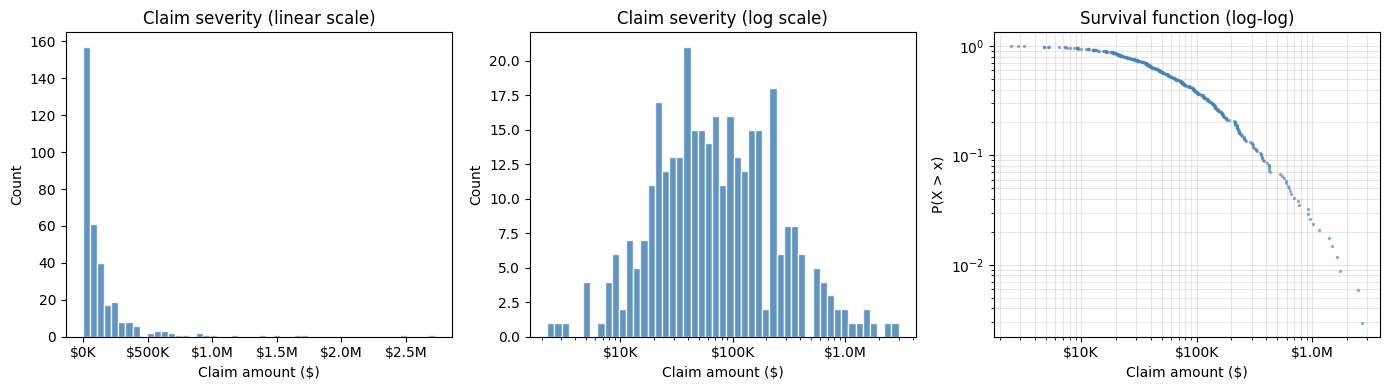

Mean / Median = 2.46x  (ratio > 1 signals right skew; > 2 signals heavy tail)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Linear histogram
axes[0].hist(all_losses, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Claim severity (linear scale)')
axes[0].set_xlabel('Claim amount ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

# Log histogram
log_bins = np.logspace(np.log10(all_losses.min() * 0.9),
                       np.log10(all_losses.max() * 1.1), 50)
axes[1].hist(all_losses, bins=log_bins, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_title('Claim severity (log scale)')
axes[1].set_xlabel('Claim amount ($)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

# Empirical survival function (log-log)
sorted_losses = np.sort(all_losses)
n = len(sorted_losses)
surv = 1 - np.arange(1, n + 1) / (n + 1)
axes[2].plot(sorted_losses, surv, '.', color='steelblue', alpha=0.5, markersize=3)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title('Survival function (log-log)')
axes[2].set_xlabel('Claim amount ($)')
axes[2].set_ylabel('P(X > x)')
axes[2].grid(True, alpha=0.3, which='both')
axes[2].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

# Compare mean vs median — a signature of right skew
ratio = all_losses.mean() / np.median(all_losses)
print(f'Mean / Median = {ratio:.2f}x  '
      f'(ratio > 1 signals right skew; > 2 signals heavy tail)')

## Fit the distribution

Adjust $\mu$ (log-mean) and $\sigma$ (log-std) to fit a lognormal to the combined claims data. Watch the PDF overlay and the survival function.

The KS statistic measures fit quality: lower is better (below 0.05 is generally good). Hit **Show MLE fit** to reveal the maximum-likelihood solution.

Toggle **Show Normal fit** to see how badly a normal distribution with the same mean and std would perform on the tail.

In [4]:
# Pre-compute MLE solution
log_data  = np.log(all_losses)
MU_MLE    = float(log_data.mean())
SIGMA_MLE = float(log_data.std(ddof=1))

mu_slider    = widgets.FloatSlider(value=11.0, min=9.5, max=13.5, step=0.05,
                                   description='\u03bc (log mean):',
                                   layout=widgets.Layout(width='500px'))
sigma_slider = widgets.FloatSlider(value=1.0, min=0.3, max=2.5, step=0.05,
                                   description='\u03c3 (log std):',
                                   layout=widgets.Layout(width='500px'))
show_normal  = widgets.Checkbox(value=False, description='Show Normal fit')
update_btn   = widgets.Button(description='Update', button_style='primary')
mle_btn      = widgets.Button(description='Show MLE fit', button_style='info')
fit_output   = widgets.Output()

x_range  = np.logspace(np.log10(all_losses.min() * 0.5),
                       np.log10(all_losses.max() * 2.0), 600)
log_bins = np.logspace(np.log10(all_losses.min() * 0.9),
                       np.log10(all_losses.max() * 1.1), 50)


def draw_fit(_=None):
    mu    = mu_slider.value
    sigma = sigma_slider.value

    dist_fit  = lognorm(s=sigma, scale=np.exp(mu))
    ks_stat, ks_p = kstest(all_losses, dist_fit.cdf)

    lev_1m = limited_expected_value(mu, sigma, 1_000_000)
    lev_5m = limited_expected_value(mu, sigma, 5_000_000)
    mean   = np.exp(mu + sigma**2 / 2)

    with fit_output:
        fit_output.clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

        # Left: density + fitted PDF
        ax1.hist(all_losses, bins=log_bins, density=True,
                 color='steelblue', edgecolor='white', alpha=0.5, label='Claims data')
        ax1.plot(x_range, dist_fit.pdf(x_range), 'b-', linewidth=2,
                 label=f'LogNormal(\u03bc={mu:.2f}, \u03c3={sigma:.2f})')
        if show_normal.value:
            norm_mean = np.exp(mu + sigma**2 / 2)
            norm_std  = norm_mean * np.sqrt(np.exp(sigma**2) - 1)
            from scipy.stats import norm as sp_norm
            ax1.plot(x_range, sp_norm.pdf(x_range, norm_mean, norm_std),
                     'r--', linewidth=1.5,
                     label=f'Normal(mean=${norm_mean/1e3:.0f}K, std=${norm_std/1e3:.0f}K)')
        ax1.set_xscale('log')
        ax1.set_title('Claim severity: data vs. fitted PDF')
        ax1.set_xlabel('Claim amount ($)')
        ax1.set_ylabel('Density')
        ax1.legend(fontsize=8)
        ax1.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

        # Right: survival function (log-log)
        sorted_l = np.sort(all_losses)
        surv_emp = 1 - np.arange(1, len(sorted_l) + 1) / (len(sorted_l) + 1)
        ax2.plot(sorted_l, surv_emp, '.', color='steelblue',
                 alpha=0.5, markersize=3, label='Empirical')
        ax2.plot(x_range, 1 - dist_fit.cdf(x_range), 'b-',
                 linewidth=2, label='LogNormal fit')
        if show_normal.value:
            norm_mean = np.exp(mu + sigma**2 / 2)
            norm_std  = norm_mean * np.sqrt(np.exp(sigma**2) - 1)
            from scipy.stats import norm as sp_norm
            surv_norm = 1 - sp_norm.cdf(x_range, norm_mean, norm_std)
            ax2.plot(x_range[surv_norm > 1e-6], surv_norm[surv_norm > 1e-6],
                     'r--', linewidth=1.5, label='Normal fit')
        ax2.axvline(1_000_000, color='darkorange', linestyle=':', linewidth=1.2,
                    label='$1M limit')
        ax2.axvline(5_000_000, color='crimson', linestyle=':', linewidth=1.2,
                    label='$5M limit')
        ax2.set_xscale('log')
        ax2.set_yscale('log')
        ax2.set_title('Survival function (log-log) — tail matters here')
        ax2.set_xlabel('Claim amount ($)')
        ax2.set_ylabel('P(X > x)')
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3, which='both')
        ax2.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

        plt.tight_layout()
        plt.show()

        # Quantile table
        pcts = [50, 75, 90, 95, 99, 99.5]
        tbl  = pd.DataFrame({
            'Percentile':       [f'{p}th' for p in pcts],
            'Empirical':        [f'${np.percentile(all_losses, p):,.0f}' for p in pcts],
            'Fitted LogNormal': [f'${dist_fit.ppf(p/100):,.0f}' for p in pcts],
        })
        display(tbl.to_html(index=False))

        quality = 'good' if ks_stat < 0.05 else ('moderate' if ks_stat < 0.10 else 'poor')
        color   = 'seagreen' if quality == 'good' else ('darkorange' if quality == 'moderate' else 'crimson')
        lines   = []
        lines.append(f'<p>KS statistic: <b>{ks_stat:.4f}</b> (p={ks_p:.3f}) — '
                     f'fit quality: <b style="color:{color}">{quality}</b>. '
                     f'MLE solution: \u03bc={MU_MLE:.3f}, \u03c3={SIGMA_MLE:.3f}.</p>')
        lines.append(f'<p>Fitted mean: <b>${mean:,.0f}</b> &nbsp;|&nbsp; '
                     f'LEV at $1M: <b>${lev_1m:,.0f}</b> &nbsp;|&nbsp; '
                     f'LEV at $5M: <b>${lev_5m:,.0f}</b></p>')
        display(HTML(''.join(lines).replace('$', '&#36;')))


def set_mle(_):
    mu_slider.value    = round(MU_MLE, 2)
    sigma_slider.value = round(SIGMA_MLE, 2)
    draw_fit()


update_btn.on_click(draw_fit)
mle_btn.on_click(set_mle)

display(widgets.VBox([
    mu_slider, sigma_slider, show_normal,
    widgets.HBox([update_btn, mle_btn]),
    fit_output
]))
draw_fit()

## Price the coverage limit

Now use your fitted distribution to price the *Cyber Premier* product. Use the MLE fit (or your own estimate) and slide the coverage limit to see how the Limited Expected Value changes.

The **per-policy additional premium** is the incremental expected claim cost above the base \$1M limit, grossed up for expenses. This is what Cyber Premier must charge on top of the standard rate to justify the higher limit.

In [5]:
BASE_LIMIT = 1_000_000

limit_slider = widgets.IntSlider(value=2_000_000, min=500_000, max=5_000_000, step=250_000,
                                 description='Limit ($):',
                                 readout_format=',d',
                                 layout=widgets.Layout(width='550px'))
lev_output   = widgets.Output()


def update_lev(change):
    limit = limit_slider.value
    mu    = mu_slider.value
    sigma = sigma_slider.value

    unlimited_mean = np.exp(mu + sigma**2 / 2)
    lev_base       = limited_expected_value(mu, sigma, BASE_LIMIT)
    lev_limit      = limited_expected_value(mu, sigma, limit)
    increment      = lev_limit - lev_base

    # Annual expected claims count across the book
    freq_total   = sum(t[1] for t in THREATS)  # ~0.22 per policy
    annual_claims = N_POLICIES * freq_total
    additional_per_policy = (annual_claims * increment / N_POLICIES) / (1 - EXPENSE_RATIO)

    with lev_output:
        lev_output.clear_output(wait=True)

        limits_range = np.linspace(100_000, 6_000_000, 300)
        lev_curve    = [limited_expected_value(mu, sigma, L) for L in limits_range]
        lev_base_arr = np.full_like(limits_range, lev_base)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

        ax1.plot(limits_range / 1e6, lev_curve, 'b-', linewidth=2, label='LEV(L)')
        ax1.axhline(unlimited_mean, color='gray', linestyle='--', linewidth=1,
                    label=f'Unlimited mean: ${unlimited_mean:,.0f}')
        ax1.axvline(BASE_LIMIT / 1e6, color='darkorange', linestyle=':', linewidth=1.5,
                    label=f'Base limit: $1M')
        ax1.axvline(limit / 1e6, color='crimson', linestyle='--', linewidth=1.5,
                    label=f'Your limit: ${limit/1e6:.1f}M')
        mask = (limits_range >= BASE_LIMIT) & (limits_range <= limit)
        ax1.fill_between(limits_range[mask] / 1e6,
                         lev_base_arr[mask], np.array(lev_curve)[mask],
                         alpha=0.25, color='crimson', label='Incremental exposure')
        ax1.set_xlabel('Coverage limit ($M)')
        ax1.set_ylabel('Limited Expected Value ($)')
        ax1.set_title('LEV by coverage limit')
        ax1.legend(fontsize=8)
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

        # Incremental cost per $500K of additional limit
        limit_steps = np.arange(500_000, 5_500_000, 500_000)
        increments  = []
        prev_lev    = limited_expected_value(mu, sigma, limit_steps[0])
        layer_labels = []
        for i in range(1, len(limit_steps)):
            curr_lev = limited_expected_value(mu, sigma, limit_steps[i])
            increments.append(curr_lev - prev_lev)
            layer_labels.append(f'${limit_steps[i-1]/1e3:.0f}K\u2013${limit_steps[i]/1e3:.0f}K')
            prev_lev = curr_lev
        colors = ['seagreen' if limit_steps[i+1] <= BASE_LIMIT else
                  ('crimson' if limit_steps[i+1] <= limit else 'lightgray')
                  for i in range(len(increments))]
        ax2.barh(layer_labels, increments, color=colors)
        ax2.set_xlabel('Expected additional claim cost per policy ($)')
        ax2.set_title('Incremental exposure per $500K layer')
        ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

        plt.tight_layout()
        plt.show()

        lines = []
        lines.append(f'<p><b>Coverage limit: ${limit:,.0f} | '
                     f'Distribution: LogNormal(\u03bc={mu:.2f}, \u03c3={sigma:.2f})</b></p>')
        lines.append(f'<p>LEV at base limit ($1M): <b>${lev_base:,.0f}</b> per claim</p>')
        lines.append(f'<p>LEV at your limit (${limit/1e6:.1f}M): <b>${lev_limit:,.0f}</b> per claim '
                     f'(+<b>${increment:,.0f}</b> incremental)</p>')
        lines.append(f'<p>Your limit captures <b>{lev_limit/unlimited_mean:.1%}</b> '
                     f'of unlimited expected losses.</p>')
        lines.append(f'<p>Additional premium needed for Cyber Premier at this limit: '
                     f'<b>${additional_per_policy:,.0f}/policy/year</b></p>')

        if limit <= BASE_LIMIT:
            lines.append('<p style="color:darkorange">Increase the limit above $1M to see '
                         'the incremental pricing for Cyber Premier.</p>')
        elif sigma >= 1.2 and increment / lev_base > 0.40:
            lines.append(f'<p style="color:crimson"><b>Heavy tail warning.</b> '
                         f'The {BASE_LIMIT/1e6:.0f}M to {limit/1e6:.0f}M layer adds '
                         f'{increment/lev_base:.0%} on top of the base layer cost. '
                         f'A normal distribution would predict a much smaller increment. '
                         f'This is why fitting the right distribution matters for high-limit pricing.</p>')
        else:
            lines.append(f'<p style="color:seagreen">At {lev_limit/unlimited_mean:.1%} '
                         f'of unlimited expected losses, this limit captures most of the exposure. '
                         f'Scroll sigma up to see how a heavier tail changes the picture.</p>')

        lines.append('<hr><p><b>Key takeaway.</b> '
                     'The LEV tells you exactly what each coverage layer is worth. '
                     'With a heavy-tailed distribution (large \u03c3), the upper layers '
                     'are disproportionately expensive — the tail holds more expected value '
                     'than you might intuitively expect. Mispricing this is how cyber insurers '
                     'end up paying for multi-million dollar claims on policies priced for '
                     'routine incidents.</p>')
        display(HTML(''.join(lines).replace('$', '&#36;')))


limit_slider.observe(update_lev, names='value')
display(widgets.VBox([limit_slider, lev_output]))
update_lev(None)

## Hints

<details><summary>Hint 1 — reading the data</summary>

The mean/median ratio tells you how skewed the distribution is. A ratio around 2x or higher suggests a heavy tail. For lognormal data, this ratio equals $e^{\sigma^2/2}$, so you can back out a rough $\sigma$ from the data before even fitting.

</details>

<details><summary>Hint 2 — finding mu</summary>

$\mu$ is the mean of $\ln X$. Compute `np.log(all_losses).mean()` in a scratch cell to get the MLE estimate directly.

</details>

<details><summary>Hint 3 — finding sigma</summary>

$\sigma$ is the std dev of $\ln X$. Try `np.log(all_losses).std()`. The resulting value is the MLE estimate of $\sigma$. In the survival function plot, a well-fitted lognormal should align with the empirical dots from the median all the way through the 99th percentile.

</details>

<details><summary>Hint 4 — why the normal fit fails in the tail</summary>

Toggle 'Show Normal fit' with $\sigma \approx 1.2$. The normal distribution puts near-zero probability above 2× the mean, so it predicts essentially no claims above ~\$600K. The empirical data has many claims above that. A normal model would price the \$1M–\$5M layer at close to zero — a catastrophic underestimate.

</details>

<details><summary>Hint 5 — interpreting the incremental bar chart</summary>

Each bar is the expected additional cost per policy per claim for that \$500K layer. Notice how the bars for the \$1M–\$1.5M layer and above may be larger than you expect. That is the heavy tail at work: the probability of landing in those upper layers is higher for lognormal than for normal.

</details>

## What's next

**Chapter 4 — Building the Rate Manual (Cyber Ratemaking).** So far every policyholder looks like Meridian Medical: same size, same profile. In reality, a hospital with multi-factor authentication and an endpoint detection platform is a fundamentally different risk than one running unpatched Windows servers with no backups.

Chapter 4 introduces rating factors: quantitative adjustments to the base premium based on security controls. You will build a simple rate manual that adjusts for MFA adoption, backup maturity, EDR deployment, and patch lag — the variables that actually predict cyber loss frequency and severity. This is where actuarial pricing meets security engineering.